# IMDb Movie Success Analysis: Revenue, Ratings & Genre Trends


## 01 — Data Cleaning & Exploratory Data Analysis

This notebook explores IMDb movie data to identify the key factors associated with movie success, including revenue, IMDb rating, audience votes, critic scores, genre performance, director performance, and release-year trends.

### Project Objective

The goal of this analysis is to answer:

> What factors influence a movie's commercial and critical success?


### Success Metrics Used

- **Commercial success:** Revenue and audience votes
- **Audience success:** IMDb rating
- **Critical success:** Metascore
- **Market trends:** Year, genre, runtime, and director patterns

## 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Visualization settings
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Load Dataset

The dataset contains movie-level information such as title, genre, director, release year, runtime, IMDb rating, votes, revenue, and metascore.

The path below is written to work both locally and on GitHub when the dataset is stored inside a `data/` folder.

In [3]:
df = pd.read_csv('IMDB-Movie-Data.csv')

In [4]:
possible_paths = [
    Path("../data/IMDB-Movie-Data.csv"),
    Path("data/IMDB-Movie-Data.csv"),
    Path("IMDB-Movie-Data.csv"),
    Path("../IMDB-Movie-Data.csv")
]

data_path = None

for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Dataset not found. Please place IMDB-Movie-Data.csv inside the data folder.")

df = pd.read_csv(data_path)

print(f"Dataset loaded successfully from: {data_path}")
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

df.head()

Dataset loaded successfully from: IMDB-Movie-Data.csv
Dataset shape: 1000 rows and 12 columns


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.10,757074,333.13,76.00
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.00,485820,126.46,65.00
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.30,157606,138.12,62.00
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.20,60545,270.32,59.00
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.20,393727,325.02,40.00


## 3. Dataset Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rank,"1,000.00",NaN,NaN,NaN,500.50,288.82,1.00,250.75,500.50,750.25,"1,000.00"
Title,1000,999,The Host,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,1000,207,"Action,Adventure,Sci-Fi",50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1000,1000,A stuffy businessman finds himself trapped ins...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Director,1000,644,Ridley Scott,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actors,1000,996,"Shia LaBeouf, Megan Fox, Josh Duhamel, Tyrese ...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,"1,000.00",NaN,NaN,NaN,"2,012.78",3.21,"2,006.00","2,010.00","2,014.00","2,016.00","2,016.00"
Runtime (Minutes),"1,000.00",NaN,NaN,NaN,113.17,18.81,66.00,100.00,111.00,123.00,191.00
Rating,"1,000.00",NaN,NaN,NaN,6.72,0.95,1.90,6.20,6.80,7.40,9.00
Votes,"1,000.00",NaN,NaN,NaN,"169,808.26","188,762.65",61.00,"36,309.00","110,799.00","239,909.75","1,791,916.00"


## 4. Data Quality Check

This section checks for duplicate records, missing values, and inconsistent column names.

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [8]:
missing_summary = (
    df.isnull()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percentage=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_percentage
Revenue (Millions),128,12.80
Metascore,64,6.40
Rank,0,0.00
Title,0,0.00
Description,0,0.00
Genre,0,0.00
Director,0,0.00
Actors,0,0.00
Runtime (Minutes),0,0.00
Year,0,0.00


### Missing Value Interpretation

Revenue and Metascore contain missing values. For portfolio reporting, it is important to be transparent:

- Revenue-related analysis should be interpreted carefully because not every movie has revenue data.
- Metascore is also missing for some movies, meaning critic-score analysis uses a smaller valid sample.
- For EDA, the original values are preserved, and imputed columns are created separately where needed.

## 5. Data Cleaning

Column names are standardized to make analysis easier and more professional.

In [9]:
df_clean = df.copy()

# Standardize column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df_clean.rename(columns={
    "runtime_minutes": "runtime_minutes",
    "revenue_millions": "revenue_millions"
}, inplace=True)

df_clean.head()

,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.10,757074,333.13,76.00
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.00,485820,126.46,65.00
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.30,157606,138.12,62.00
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.20,60545,270.32,59.00
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.20,393727,325.02,40.00


In [10]:
# Create missing value indicators before imputation
df_clean["revenue_missing"] = df_clean["revenue_millions"].isna()
df_clean["metascore_missing"] = df_clean["metascore"].isna()

# Create imputed columns for optional modeling/dashboard use
df_clean["revenue_millions_filled"] = df_clean["revenue_millions"].fillna(df_clean["revenue_millions"].median())
df_clean["metascore_filled"] = df_clean["metascore"].fillna(df_clean["metascore"].mean())

# Basic validation
print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Cleaned dataset shape: (1000, 16)


,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore,revenue_missing,metascore_missing,revenue_millions_filled,metascore_filled
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.10,757074,333.13,76.00,False,False,333.13,76.00
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.00,485820,126.46,65.00,False,False,126.46,65.00
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.30,157606,138.12,62.00,False,False,138.12,62.00
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.20,60545,270.32,59.00,False,False,270.32,59.00
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.20,393727,325.02,40.00,False,False,325.02,40.00


## 6. Feature Engineering

New features are created to support better analysis:

- `primary_genre`: first genre listed for each movie
- `genre_count`: number of genres assigned to a movie
- `movie_age`: age of the movie relative to the latest year in the dataset
- `rating_category`: grouped rating bands
- `revenue_category`: grouped revenue bands

In [11]:
df_clean["primary_genre"] = df_clean["genre"].str.split(",").str[0]
df_clean["genre_count"] = df_clean["genre"].str.split(",").str.len()

latest_year = df_clean["year"].max()
df_clean["movie_age"] = latest_year - df_clean["year"]

df_clean["rating_category"] = pd.cut(
    df_clean["rating"],
    bins=[0, 5, 6, 7, 8, 10],
    labels=["Low", "Below Average", "Average", "Good", "Excellent"]
)

df_clean["revenue_category"] = pd.cut(
    df_clean["revenue_millions"],
    bins=[0, 50, 100, 250, 500, np.inf],
    labels=["Low", "Moderate", "High", "Very High", "Blockbuster"]
)

df_clean[["title", "genre", "primary_genre", "genre_count", "year", "movie_age", "rating_category", "revenue_category"]].head()

,title,genre,primary_genre,genre_count,year,movie_age,rating_category,revenue_category
0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",Action,3,2014,2,Excellent,Very High
1,Prometheus,"Adventure,Mystery,Sci-Fi",Adventure,3,2012,4,Average,High
2,Split,"Horror,Thriller",Horror,2,2016,0,Good,High
3,Sing,"Animation,Comedy,Family",Animation,3,2016,0,Good,Very High
4,Suicide Squad,"Action,Adventure,Fantasy",Action,3,2016,0,Average,Very High


### Create Genre-Level Dataset

Movies can belong to multiple genres. To analyze genres properly, the genre column is split so each movie appears once per genre.

In [12]:
genre_df = df_clean.copy()

genre_df["genre"] = genre_df["genre"].str.split(",")
genre_df = genre_df.explode("genre")
genre_df["genre"] = genre_df["genre"].str.strip()

print(f"Original dataset rows: {df_clean.shape[0]}")
print(f"Genre-level dataset rows: {genre_df.shape[0]}")

genre_df[["title", "genre", "rating", "revenue_millions"]].head(10)

Original dataset rows: 1000
Genre-level dataset rows: 2555


,title,genre,rating,revenue_millions
0,Guardians of the Galaxy,Action,8.10,333.13
0,Guardians of the Galaxy,Adventure,8.10,333.13
0,Guardians of the Galaxy,Sci-Fi,8.10,333.13
1,Prometheus,Adventure,7.00,126.46
1,Prometheus,Mystery,7.00,126.46
1,Prometheus,Sci-Fi,7.00,126.46
2,Split,Horror,7.30,138.12
2,Split,Thriller,7.30,138.12
3,Sing,Animation,7.20,270.32
3,Sing,Comedy,7.20,270.32


## 7. Exploratory Data Analysis

### 7.1 Movie Release Trend by Year

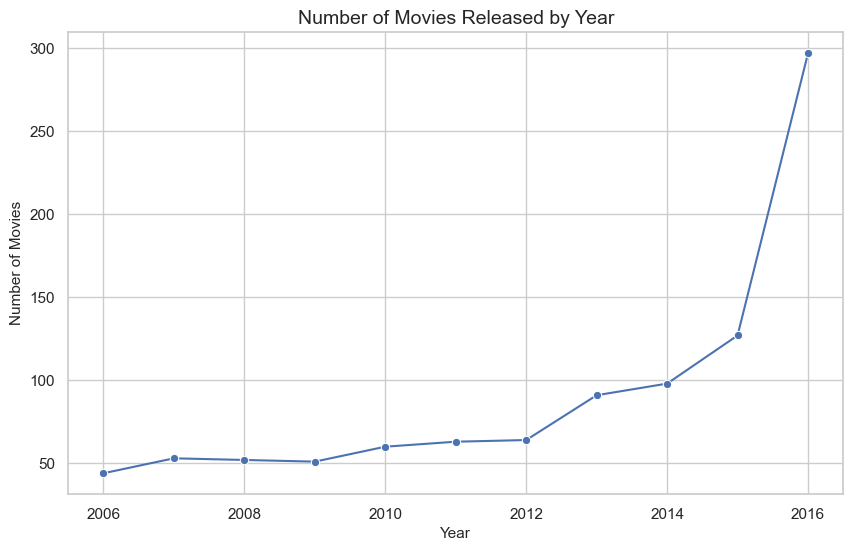

In [13]:
movies_by_year = df_clean["year"].value_counts().sort_index()

ax = sns.lineplot(x=movies_by_year.index, y=movies_by_year.values, marker="o", color="#4C72B0")
ax.set_title("Number of Movies Released by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Movies")
plt.show()

### 7.2 IMDb Rating Distribution

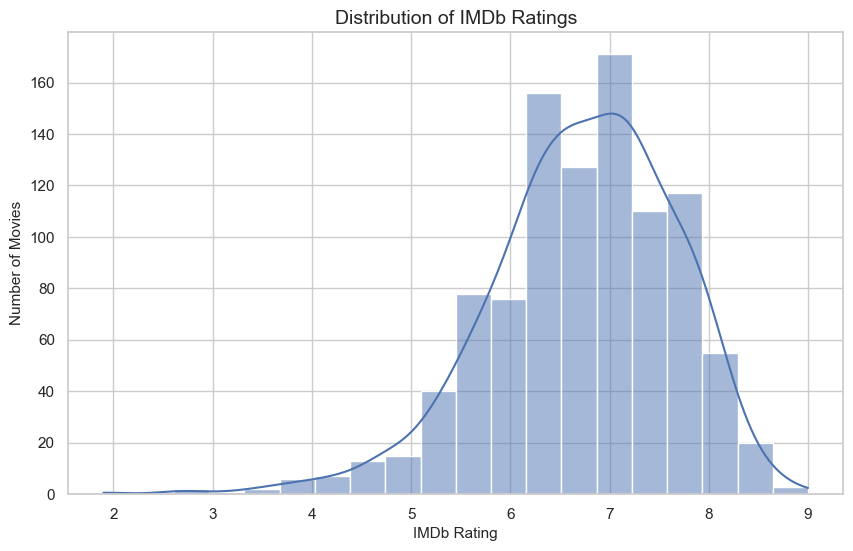

Average IMDb Rating: 6.72
Median IMDb Rating: 6.8


In [14]:
ax = sns.histplot(df_clean["rating"], bins=20, kde=True, color="#4C72B0")
ax.set_title("Distribution of IMDb Ratings")
ax.set_xlabel("IMDb Rating")
ax.set_ylabel("Number of Movies")
plt.show()

print("Average IMDb Rating:", round(df_clean["rating"].mean(), 2))
print("Median IMDb Rating:", round(df_clean["rating"].median(), 2))

### 7.3 Revenue Distribution

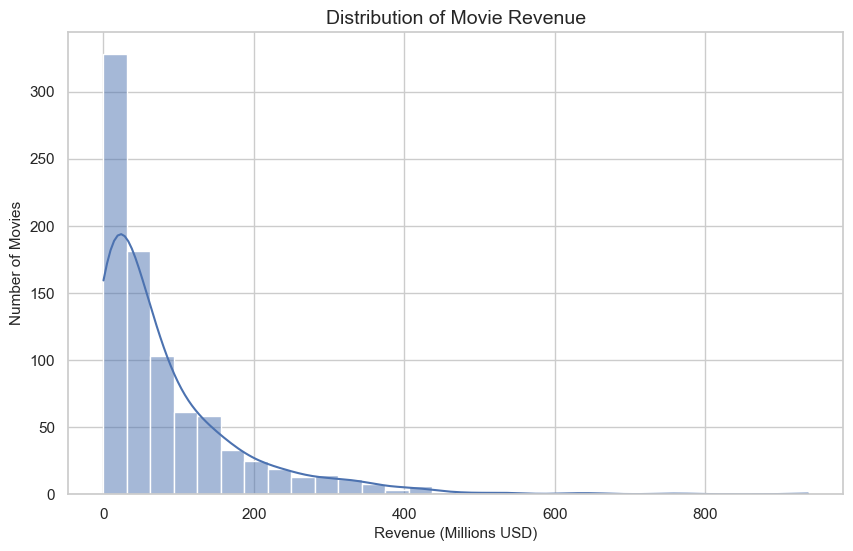

Average Revenue: 82.96 million USD
Median Revenue: 47.98 million USD


In [15]:
revenue_data = df_clean.dropna(subset=["revenue_millions"])

ax = sns.histplot(revenue_data["revenue_millions"], bins=30, kde=True, color="#4C72B0")
ax.set_title("Distribution of Movie Revenue")
ax.set_xlabel("Revenue (Millions USD)")
ax.set_ylabel("Number of Movies")
plt.show()

print("Average Revenue:", round(revenue_data["revenue_millions"].mean(), 2), "million USD")
print("Median Revenue:", round(revenue_data["revenue_millions"].median(), 2), "million USD")

### 7.4 Top 10 Highest Rated Movies

In [16]:
top_rated_movies = (
    df_clean[["title", "year", "director", "rating", "votes"]]
    .sort_values("rating", ascending=False)
    .head(10)
)

top_rated_movies

,title,year,director,rating,votes
54,The Dark Knight,2008,Christopher Nolan,9.00,1791916
80,Inception,2010,Christopher Nolan,8.80,1583625
117,Dangal,2016,Nitesh Tiwari,8.80,48969
36,Interstellar,2014,Christopher Nolan,8.60,1047747
249,The Intouchables,2011,Olivier Nakache,8.60,557965
96,Kimi no na wa,2016,Makoto Shinkai,8.60,34110
64,The Prestige,2006,Christopher Nolan,8.50,913152
99,The Departed,2006,Martin Scorsese,8.50,937414
476,The Lives of Others,2006,Florian Henckel von Donnersmarck,8.50,278103
124,The Dark Knight Rises,2012,Christopher Nolan,8.50,1222645


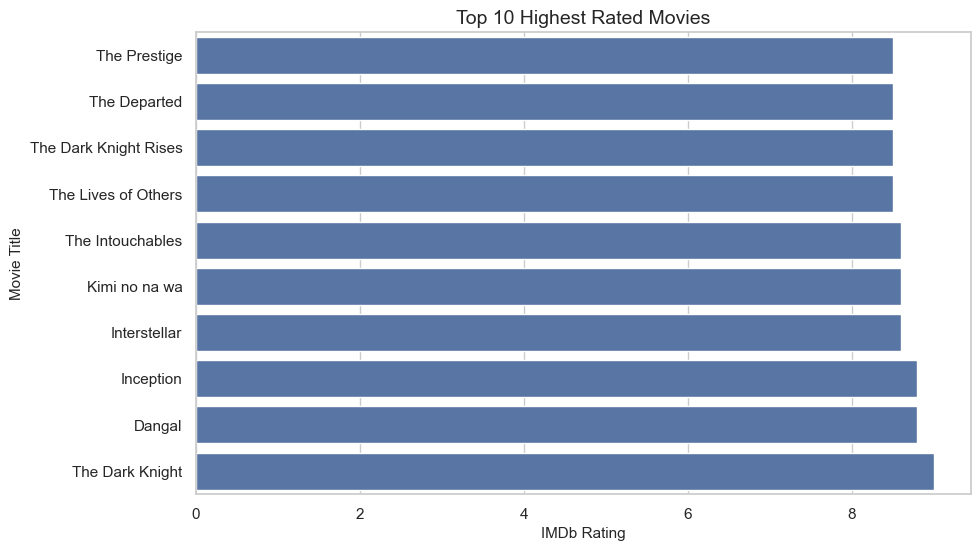

In [17]:
ax = sns.barplot(
    data=top_rated_movies.sort_values("rating", ascending=True),
    x="rating",
    y="title",
    color="#4C72B0"
)
ax.set_title("Top 10 Highest Rated Movies")
ax.set_xlabel("IMDb Rating")
ax.set_ylabel("Movie Title")
plt.show()

### 7.5 Top 10 Highest Revenue Movies

In [18]:
top_revenue_movies = (
    df_clean.dropna(subset=["revenue_millions"])
    [["title", "year", "director", "rating", "revenue_millions"]]
    .sort_values("revenue_millions", ascending=False)
    .head(10)
)

top_revenue_movies

,title,year,director,rating,revenue_millions
50,Star Wars: Episode VII - The Force Awakens,2015,J.J. Abrams,8.10,936.63
87,Avatar,2009,James Cameron,7.80,760.51
85,Jurassic World,2015,Colin Trevorrow,7.00,652.18
76,The Avengers,2012,Joss Whedon,8.10,623.28
54,The Dark Knight,2008,Christopher Nolan,9.00,533.32
12,Rogue One,2016,Gareth Edwards,7.90,532.17
119,Finding Dory,2016,Andrew Stanton,7.40,486.29
94,Avengers: Age of Ultron,2015,Joss Whedon,7.40,458.99
124,The Dark Knight Rises,2012,Christopher Nolan,8.50,448.13
578,The Hunger Games: Catching Fire,2013,Francis Lawrence,7.60,424.65


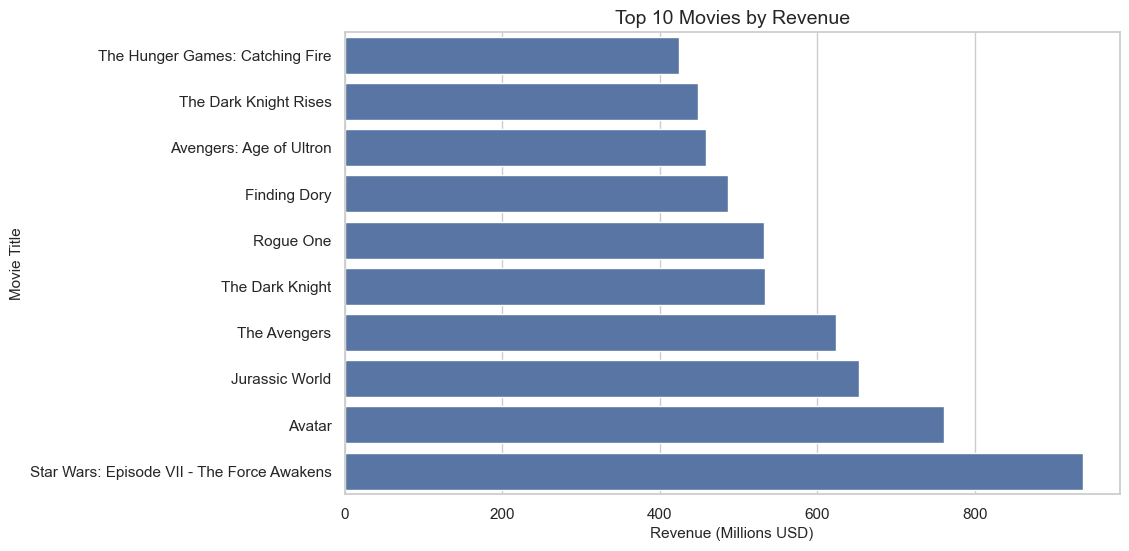

In [19]:
ax = sns.barplot(
    data=top_revenue_movies.sort_values("revenue_millions", ascending=True),
    x="revenue_millions",
    y="title",
    color="#4C72B0"
)
ax.set_title("Top 10 Movies by Revenue")
ax.set_xlabel("Revenue (Millions USD)")
ax.set_ylabel("Movie Title")
plt.show()

## 8. Relationship Analysis

### 8.1 IMDb Rating vs Revenue

This chart helps determine whether higher-rated movies also generate higher revenue.

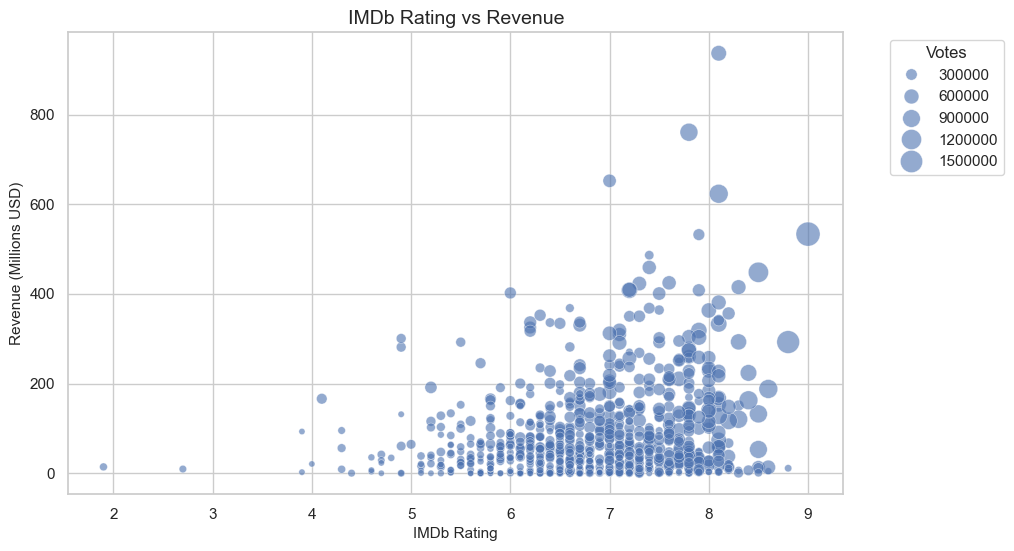

In [20]:
rating_revenue_df = df_clean.dropna(subset=["revenue_millions"])

ax = sns.scatterplot(
    data=rating_revenue_df,
    x="rating",
    y="revenue_millions",
    size="votes",
    sizes=(20, 300),
    alpha=0.6,
    color="#4C72B0"
)
ax.set_title("IMDb Rating vs Revenue")
ax.set_xlabel("IMDb Rating")
ax.set_ylabel("Revenue (Millions USD)")
plt.legend(title="Votes", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### 8.2 Votes vs Revenue

Votes can be used as a proxy for audience reach and popularity.

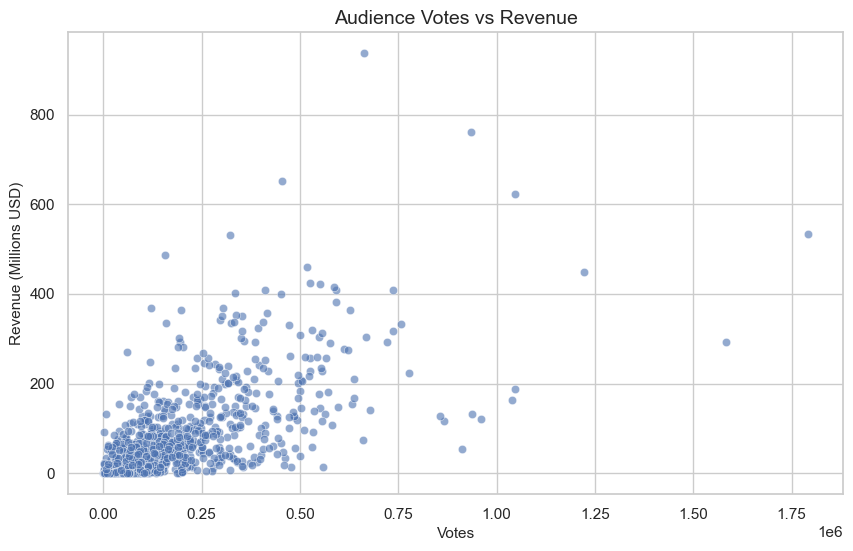

In [21]:
ax = sns.scatterplot(
    data=rating_revenue_df,
    x="votes",
    y="revenue_millions",
    alpha=0.6,
    color="#4C72B0"
)
ax.set_title("Audience Votes vs Revenue")
ax.set_xlabel("Votes")
ax.set_ylabel("Revenue (Millions USD)")
plt.show()

### 8.3 IMDb Rating vs Metascore

This chart compares audience ratings with critic scores.

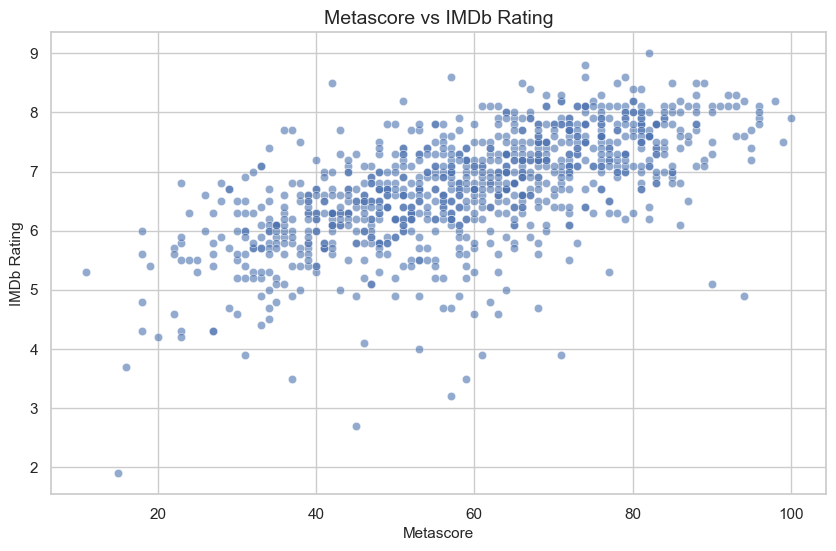

In [22]:
rating_metascore_df = df_clean.dropna(subset=["metascore"])

ax = sns.scatterplot(
    data=rating_metascore_df,
    x="metascore",
    y="rating",
    alpha=0.6,
    color="#4C72B0"
)
ax.set_title("Metascore vs IMDb Rating")
ax.set_xlabel("Metascore")
ax.set_ylabel("IMDb Rating")
plt.show()

### 8.4 Correlation Analysis

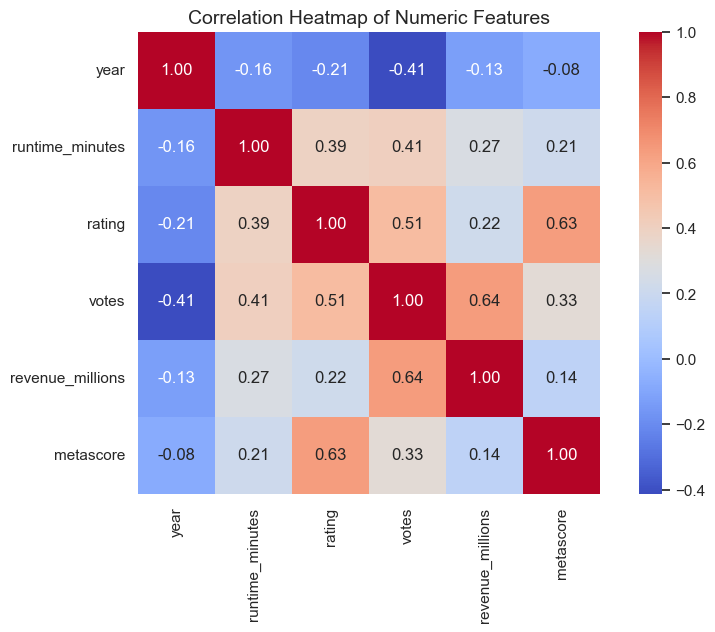

,year,runtime_minutes,rating,votes,revenue_millions,metascore
year,1.00,-0.16,-0.21,-0.41,-0.13,-0.08
runtime_minutes,-0.16,1.00,0.39,0.41,0.27,0.21
rating,-0.21,0.39,1.00,0.51,0.22,0.63
votes,-0.41,0.41,0.51,1.00,0.64,0.33
revenue_millions,-0.13,0.27,0.22,0.64,1.00,0.14
metascore,-0.08,0.21,0.63,0.33,0.14,1.00


In [23]:
numeric_cols = [
    "year",
    "runtime_minutes",
    "rating",
    "votes",
    "revenue_millions",
    "metascore"
]

corr = df_clean[numeric_cols].corr()

ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.show()

corr

## 9. Genre Analysis

### 9.1 Movie Count by Genre

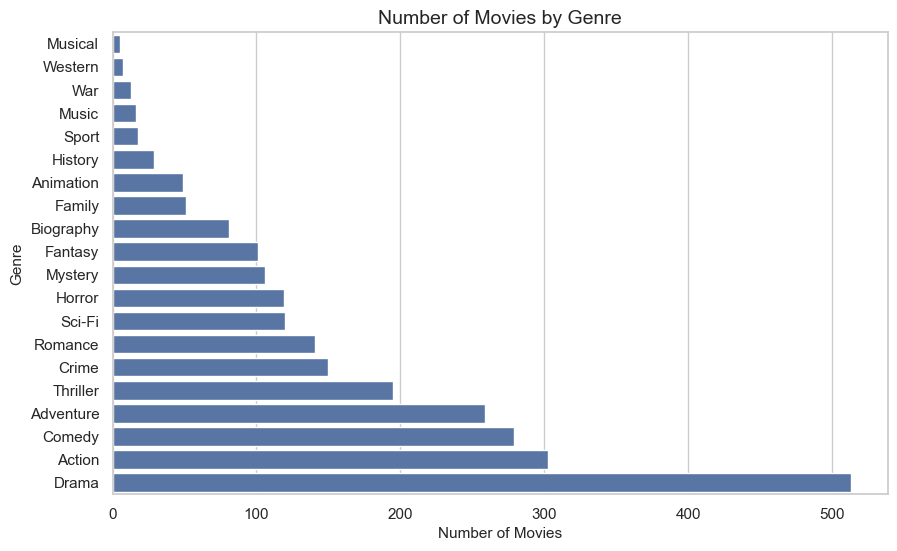

,genre,movie_count
0,Drama,513
1,Action,303
2,Comedy,279
3,Adventure,259
4,Thriller,195
5,Crime,150
6,Romance,141
7,Sci-Fi,120
8,Horror,119
9,Mystery,106


In [24]:
genre_counts = genre_df["genre"].value_counts().reset_index()
genre_counts.columns = ["genre", "movie_count"]

ax = sns.barplot(
    data=genre_counts.sort_values("movie_count", ascending=True),
    x="movie_count",
    y="genre",
    color="#4C72B0"
)
ax.set_title("Number of Movies by Genre")
ax.set_xlabel("Number of Movies")
ax.set_ylabel("Genre")
plt.show()

genre_counts

### 9.2 Average IMDb Rating by Genre

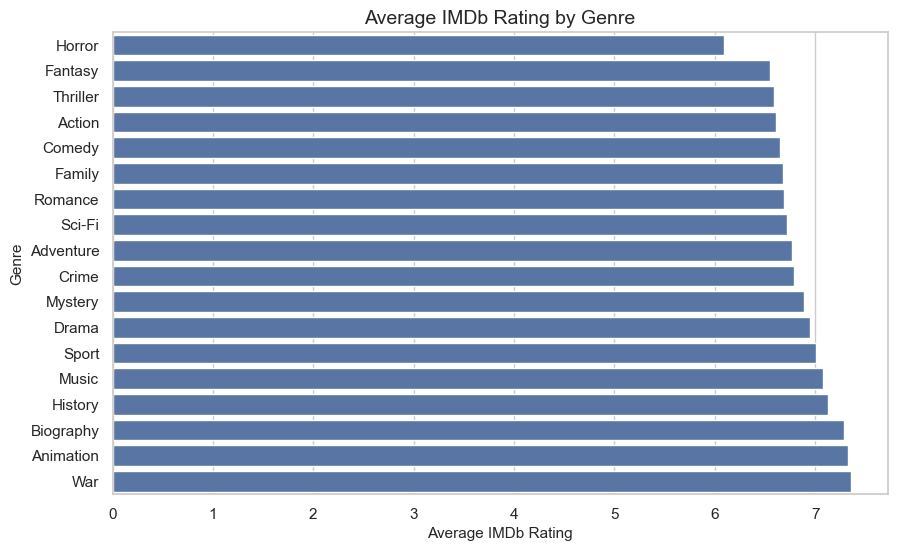

,genre,movie_count,average_rating
0,War,13,7.35
1,Animation,49,7.32
2,Biography,81,7.29
3,History,29,7.13
4,Music,16,7.08
5,Sport,18,7.01
6,Drama,513,6.95
7,Mystery,106,6.89
8,Crime,150,6.79
9,Adventure,259,6.77


In [25]:
genre_rating = (
    genre_df.groupby("genre")
    .agg(movie_count=("title", "count"), average_rating=("rating", "mean"))
    .query("movie_count >= 10")
    .sort_values("average_rating", ascending=False)
    .reset_index()
)

ax = sns.barplot(
    data=genre_rating.sort_values("average_rating", ascending=True),
    x="average_rating",
    y="genre",
    color="#4C72B0"
)
ax.set_title("Average IMDb Rating by Genre")
ax.set_xlabel("Average IMDb Rating")
ax.set_ylabel("Genre")
plt.show()

genre_rating

### 9.3 Average Revenue by Genre

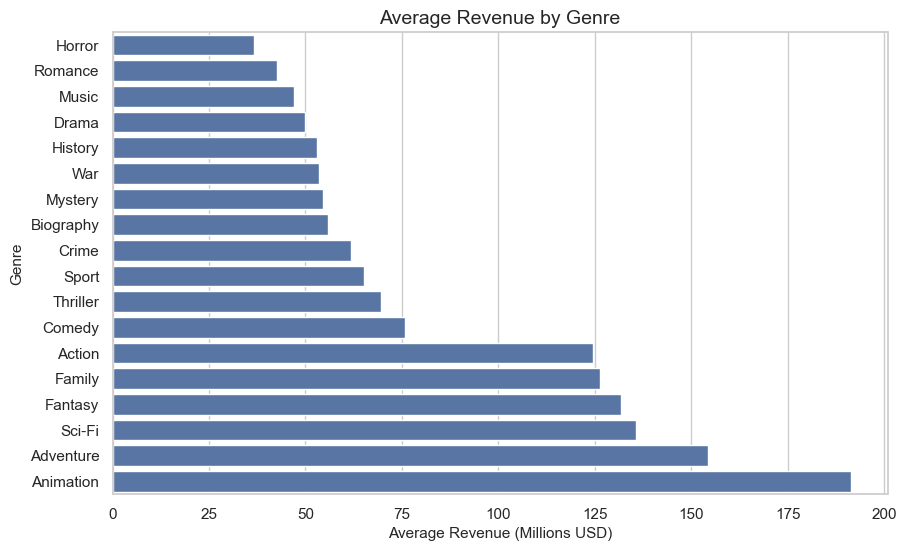

,genre,movie_count,average_revenue
0,Animation,47,191.22
1,Adventure,252,154.18
2,Sci-Fi,110,135.55
3,Fantasy,93,131.85
4,Family,49,126.18
5,Action,286,124.49
6,Comedy,255,75.75
7,Thriller,153,69.58
8,Sport,16,65.04
9,Crime,130,61.80


In [26]:
genre_revenue = (
    genre_df.dropna(subset=["revenue_millions"])
    .groupby("genre")
    .agg(movie_count=("title", "count"), average_revenue=("revenue_millions", "mean"))
    .query("movie_count >= 10")
    .sort_values("average_revenue", ascending=False)
    .reset_index()
)

ax = sns.barplot(
    data=genre_revenue.sort_values("average_revenue", ascending=True),
    x="average_revenue",
    y="genre",
    color="#4C72B0"
)
ax.set_title("Average Revenue by Genre")
ax.set_xlabel("Average Revenue (Millions USD)")
ax.set_ylabel("Genre")
plt.show()

genre_revenue

## 10. Director Analysis

To avoid misleading rankings, directors are only compared when they have at least two movies in the dataset.

In [27]:
director_summary = (
    df_clean.groupby("director")
    .agg(
        movie_count=("title", "count"),
        average_rating=("rating", "mean"),
        average_revenue=("revenue_millions", "mean"),
        total_revenue=("revenue_millions", "sum")
    )
    .query("movie_count >= 2")
    .sort_values("average_rating", ascending=False)
    .reset_index()
)

director_summary.head(10)

,director,movie_count,average_rating,average_revenue,total_revenue
0,Christopher Nolan,5,8.68,303.02,"1,515.09"
1,Damien Chazelle,2,8.40,82.08,164.15
2,Rajkumar Hirani,2,8.30,8.54,17.09
3,Pete Docter,2,8.25,324.72,649.43
4,Dean DeBlois,2,8.00,197.19,394.39
5,Mel Gibson,2,8.00,58.99,117.98
6,Martin Scorsese,5,7.92,91.62,458.11
7,Quentin Tarantino,4,7.90,112.48,337.44
8,Wes Anderson,3,7.90,41.86,125.58
9,Gabriele Muccino,2,7.85,116.27,232.54


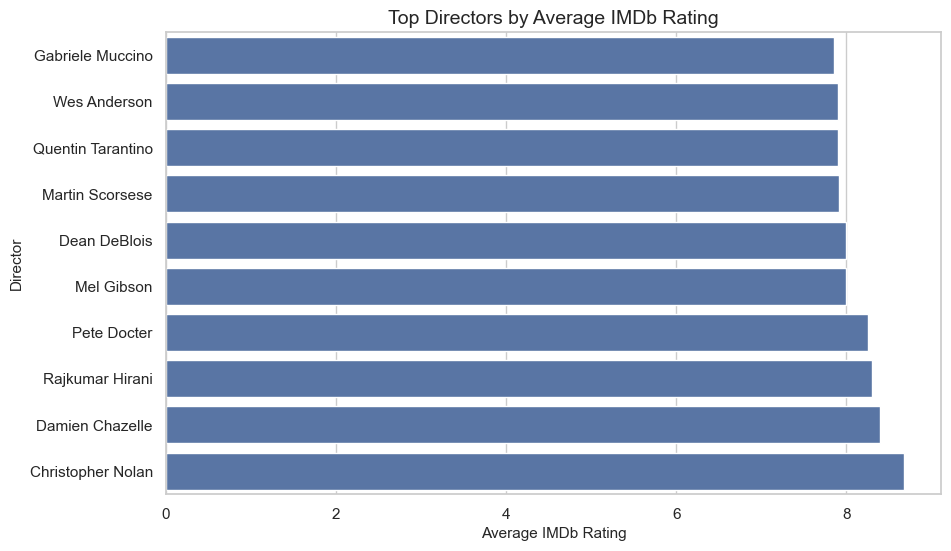

In [28]:
top_directors_rating = director_summary.head(10)

ax = sns.barplot(
    data=top_directors_rating.sort_values("average_rating", ascending=True),
    x="average_rating",
    y="director",
    color="#4C72B0"
)
ax.set_title("Top Directors by Average IMDb Rating")
ax.set_xlabel("Average IMDb Rating")
ax.set_ylabel("Director")
plt.show()

## 11. Yearly Trends

### 11.1 Average Rating and Revenue by Year

In [29]:
yearly_summary = (
    df_clean.groupby("year")
    .agg(
        movie_count=("title", "count"),
        average_rating=("rating", "mean"),
        average_revenue=("revenue_millions", "mean"),
        total_revenue=("revenue_millions", "sum"),
        average_votes=("votes", "mean")
    )
    .reset_index()
)

yearly_summary

,year,movie_count,average_rating,average_revenue,total_revenue,average_votes
0,2006,44,7.12,86.30,"3,624.46","269,289.95"
1,2007,53,7.13,87.88,"4,306.23","244,331.04"
2,2008,52,6.78,99.08,"5,053.22","275,505.38"
3,2009,51,6.96,112.60,"5,292.26","255,780.65"
4,2010,60,6.83,105.08,"5,989.65","252,782.32"
5,2011,63,6.84,87.61,"5,431.96","240,790.30"
6,2012,64,6.92,107.97,"6,910.29","285,226.09"
7,2013,91,6.81,87.12,"7,666.72","219,049.65"
8,2014,98,6.84,85.08,"7,997.40","203,930.22"
9,2015,127,6.60,78.36,"8,854.12","115,726.22"


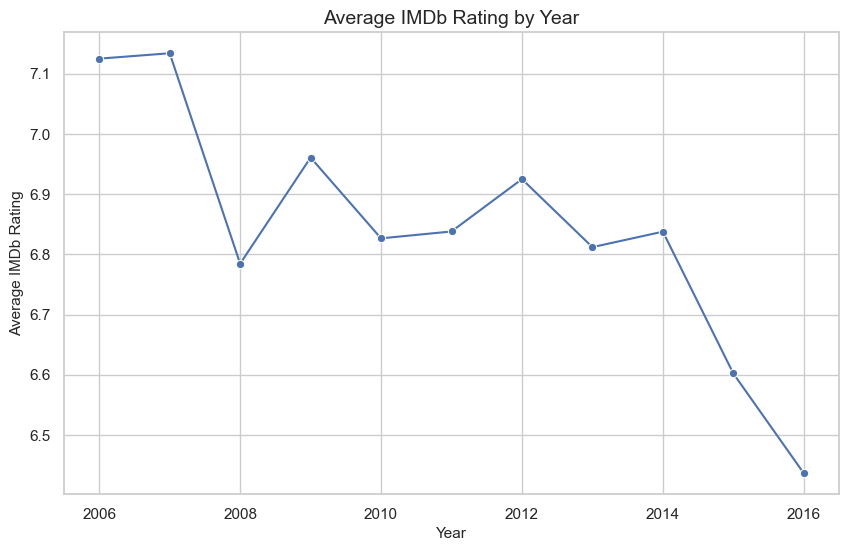

In [30]:
ax = sns.lineplot(data=yearly_summary, x="year", y="average_rating", marker="o", color="#4C72B0")
ax.set_title("Average IMDb Rating by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average IMDb Rating")
plt.show()

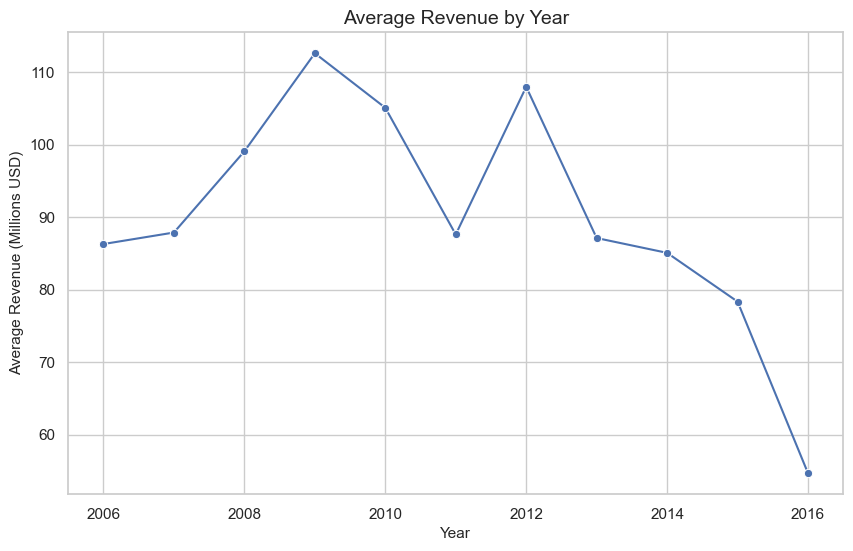

In [31]:
ax = sns.lineplot(data=yearly_summary, x="year", y="average_revenue", marker="o", color="#4C72B0")
ax.set_title("Average Revenue by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Revenue (Millions USD)")
plt.show()

## 12. Save Cleaned Data for Dashboard and Machine Learning

The cleaned datasets are saved for use in the Power BI dashboard and the machine learning notebook.

In [32]:
output_dir = Path("../data/processed")
if not output_dir.exists():
    output_dir = Path("data/processed")

output_dir.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(output_dir / "imdb_movies_cleaned.csv", index=False)
genre_df.to_csv(output_dir / "imdb_movies_genre_level.csv", index=False)

print(f"Cleaned movie dataset saved to: {output_dir / 'imdb_movies_cleaned.csv'}")
print(f"Genre-level dataset saved to: {output_dir / 'imdb_movies_genre_level.csv'}")

Cleaned movie dataset saved to: data\processed\imdb_movies_cleaned.csv
Genre-level dataset saved to: data\processed\imdb_movies_genre_level.csv


## 13. Key Insights

Based on the exploratory analysis:

1. Movie revenue is highly skewed, with a small number of blockbuster movies generating very high revenue.
2. IMDb ratings are mostly concentrated between 6 and 8, suggesting most movies in the dataset received moderate to good audience ratings.
3. Audience votes appear to have a stronger relationship with revenue than IMDb rating alone.
4. IMDb rating and Metascore show a positive relationship, meaning audience and critic evaluations often move in the same direction.
5. Genre-level analysis gives more accurate results when movies with multiple genres are split into separate genre rows.
6. Director comparisons are more reliable when filtered to directors with multiple movies.
7. High revenue does not always mean high IMDb rating, showing that commercial success and audience satisfaction are related but not identical.

## 14. Business Recommendations

1. Use audience engagement metrics such as votes as an important signal of commercial success.
2. Analyze genres separately because multi-genre movies can hide valuable trends.
3. Consider both IMDb rating and Metascore when evaluating overall movie quality.
4. Avoid ranking directors based on only one movie, as this can create misleading conclusions.
5. Use the cleaned dataset and engineered features for the next phase: machine learning revenue prediction.